### Setup

In [ ]:
!git clone https://github.com/ayeung009/APS360-Project.git

!pip install torch torchvision pandas pillow tqdm scikit-learn --quiet

Cloning into 'APS360-Project'...
remote: Enumerating objects: 1442, done.
remote: Counting objects: 100% (1442/1442), done.
remote: Compressing objects: 100% (1418/1418), done.
remote: Total 1442 (delta 72), reused 1308 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (1442/1442), 27.00 MiB | 15.23 MiB/s, done.
Resolving deltas: 100% (72/72), done.


In [ ]:
import os
import re
import random
import itertools
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms as T
import torchvision.models as models
from sklearn.model_selection import train_test_split
from tqdm import tqdm

SEED = 360
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


### Paths

In [ ]:
PROJECT_ROOT = Path("/content/APS360-Project")
FINAL_LABELS_CSV = PROJECT_ROOT / "data" / "final_merged_dataset" / "final_labels.csv"
CHECKPOINT_DIR = Path("/content/checkpoints/cnn_transformer")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("Labels file:", FINAL_LABELS_CSV, "| exists:", FINAL_LABELS_CSV.exists())

Labels file: /content/APS360-Project/data/final_merged_dataset/final_labels.csv | exists: True


### Load data


In [ ]:
OLD_ROBOFLOW_PREFIX = "Logic-Gates-Detection-12"
NEW_ROBOFLOW_PREFIX = "Logic Gates Detection.v12i.coco"

def resolve_path(p):
    if p.startswith("logic_dataset/"):
        return str(PROJECT_ROOT / "data" / "self_generated_data" / p)
    else:
        p = p.replace(OLD_ROBOFLOW_PREFIX, NEW_ROBOFLOW_PREFIX)
        return str(PROJECT_ROOT / "data" / p)

labels_df = pd.read_csv(FINAL_LABELS_CSV)
labels_df["full_path"] = labels_df["image_path"].apply(resolve_path)

print(f"Total examples: {len(labels_df)}")
print(labels_df["source"].value_counts())
labels_df.head()

Total examples: 1061
source
self_generated    1000
roboflow            61
Name: count, dtype: int64


,image_path,expression,source,n_inputs,full_path
0,Logic-Gates-Detection-12/train/136_png.rf.d78e...,((A xor B) xor C),roboflow,3,/content/APS360-Project/data/Logic Gates Detec...
1,Logic-Gates-Detection-12/train/Screenshot-2023...,((A and (not B)) or (B and (not A))),roboflow,2,/content/APS360-Project/data/Logic Gates Detec...
2,Logic-Gates-Detection-12/train/35_png.rf.4ebb0...,((A or B) and (C or D) and (B or D)),roboflow,4,/content/APS360-Project/data/Logic Gates Detec...
3,Logic-Gates-Detection-12/train/Screenshot-2023...,(A or B),roboflow,2,/content/APS360-Project/data/Logic Gates Detec...
4,Logic-Gates-Detection-12/train/Screenshot-2023...,(A xnor B),roboflow,2,/content/APS360-Project/data/Logic Gates Detec...


In [ ]:
# Verify image paths actually resolve before training on them
missing = [p for p in labels_df["full_path"] if not Path(p).exists()]
print(f"Missing files: {len(missing)} / {len(labels_df)}")
if missing:
    print("First few missing paths:", missing[:5])

Missing files: 0 / 1061


### Train / val / test split — 70 / 15 / 15

In [ ]:
train_df, temp_df = train_test_split(
    labels_df, test_size=0.30, random_state=SEED,
    stratify=labels_df["source"],
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED,
    stratify=temp_df["source"],
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 742 | Val: 159 | Test: 160


### Tokenizer



In [ ]:
SPECIAL = ["<pad>", "<bos>", "<eos>"]

TOKENS = [
    "A", "B", "C", "D", "E",
    "and", "or", "xor", "nand", "nor", "xnor", "not",
    "(", ")",
]

vocab = SPECIAL + TOKENS
stoi = {token: i for i, token in enumerate(vocab)}
itos = {i: t for t, i in stoi.items()}

VOCAB_SIZE = len(vocab)
PAD_IDX = stoi["<pad>"]
BOS_IDX = stoi["<bos>"]
EOS_IDX = stoi["<eos>"]

print(f"Vocab size: {VOCAB_SIZE}")

def tokenize(expr):
    expr = expr.replace("(", " ( ").replace(")", " ) ")
    tokens = expr.split()
    ids = [BOS_IDX]
    for t in tokens:
        ids.append(stoi[t])
    ids.append(EOS_IDX)
    return ids

def detokenize(ids):
    tokens = [itos[i] for i in ids if i not in (PAD_IDX, BOS_IDX, EOS_IDX)]
    out = []
    for t in tokens:
        if t == ")" and out and out[-1] == " ":
            out.pop()
        out.append(t)
        if t != "(":
            out.append(" ")
    return "".join(out).strip()

_test_expr = "(D xnor A) nor B"
_ids = tokenize(_test_expr)
print(f"'{_test_expr}' -> {_ids} -> '{detokenize(_ids)}'")

Vocab size: 17
'(D xnor A) nor B' -> [1, 15, 6, 13, 3, 16, 12, 4, 2] -> '(D xnor A) nor B'


### Dataset



In [ ]:
IMAGE_SIZE = 224

train_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.Grayscale(num_output_channels=3),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.RandomRotation(degrees=3),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class LogicDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row.full_path).convert("RGB")
        img = self.transform(img)
        label = torch.tensor(tokenize(row.expression), dtype=torch.long)
        return img, label

### Collate + DataLoaders

In [ ]:
def collate(batch):
    images, labels = zip(*batch)
    images = torch.stack(images)
    labels = pad_sequence(labels, batch_first=True, padding_value=PAD_IDX)
    return images, labels

BATCH_SIZE = 16

train_loader = DataLoader(
    LogicDataset(train_df, train_transform),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate,
)
val_loader = DataLoader(
    LogicDataset(val_df, eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate,
)
test_loader = DataLoader(
    LogicDataset(test_df, eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate,
)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train batches: 47 | Val: 10 | Test: 10


### Sanity check

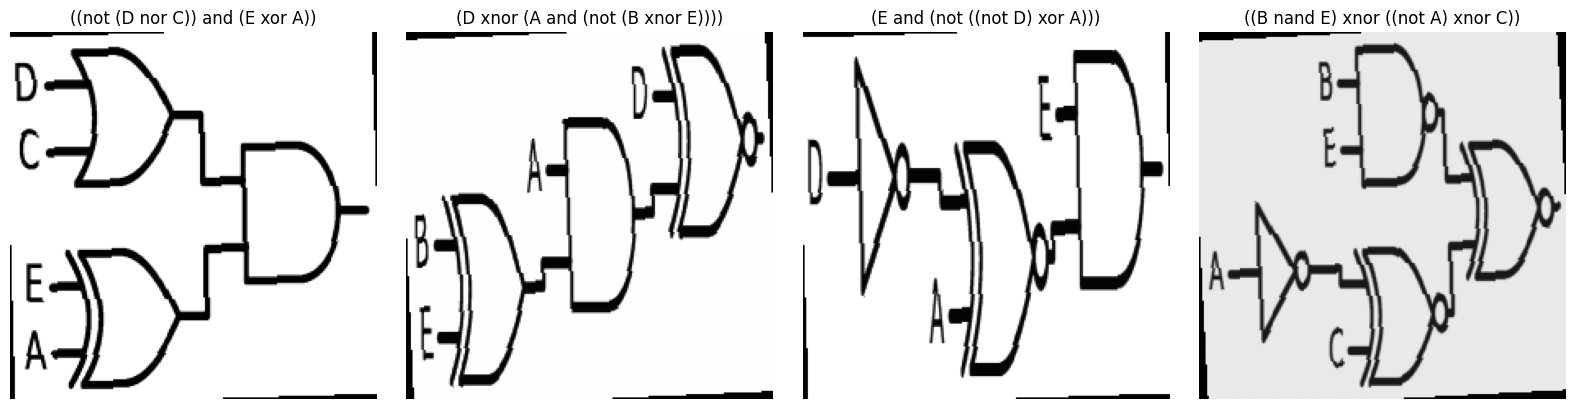

In [ ]:
def sanity_check(loader, n=4):
    images, labels = next(iter(loader))
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    for i in range(n):
        img = images[i] * std + mean
        axes[i].imshow(img.permute(1, 2, 0).clamp(0, 1))
        axes[i].set_title(detokenize(labels[i].tolist()))
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

sanity_check(train_loader)

### Positional encoding



In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64):
        super().__init__()
        self.pos_embedding = nn.Embedding(max_len, d_model)

    def forward(self, x):
        seq_len = x.size(1)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        return x + self.pos_embedding(positions)

### CNN + Transformer encoder


In [ ]:
class CNNEncoder(nn.Module):
    def __init__(self, d_model=512, nhead=8, num_layers=4, max_len=64):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])  # drop avgpool + fc
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(layer, num_layers=num_layers)

    def forward(self, images):
        features = self.backbone(images)                 # (B, 512, 7, 7)
        B, C, H, W = features.shape
        seq = features.flatten(2).permute(0, 2, 1)        # (B, 49, 512)
        seq = self.pos_encoding(seq)
        return self.transformer_encoder(seq)               # (B, 49, 512)

### Decoder



In [ ]:
class ExpressionDecoder(nn.Module):
    def __init__(self, vocab_size, d_model, nhead=8, num_layers=4, max_len=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.decoder = nn.TransformerDecoder(layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, memory, tokens, tgt_key_padding_mask=None):
        seq_len = tokens.size(1)
        x = self.pos_encoding(self.embedding(tokens))

        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(tokens.device)
        causal_mask = causal_mask == float("-inf")  # bool form, matches padding mask dtype

        out = self.decoder(
            x, memory,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
        )
        return self.fc(out)

### Full model

In [ ]:
class CNNTransformerModel(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, images, tokens, tgt_key_padding_mask=None):
        memory = self.encoder(images)
        return self.decoder(memory, tokens, tgt_key_padding_mask=tgt_key_padding_mask)

D_MODEL = 512  # matches ResNet-18's final channel count -- no projection layer needed

encoder = CNNEncoder(d_model=D_MODEL)
decoder = ExpressionDecoder(VOCAB_SIZE, D_MODEL)
model = CNNTransformerModel(encoder, decoder).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 237MB/s]


Trainable parameters: 40,685,137


### Boolean equivalence checker


In [ ]:
BINOPS = {"and", "or", "xor", "nand", "nor", "xnor"}

def tokenize_str(expr):
    expr = expr.replace("(", " ( ").replace(")", " ) ")
    return expr.split()

class _Parser:
    def __init__(self, tokens):
        self.tokens = tokens
        self.pos = 0
    def peek(self):
        return self.tokens[self.pos] if self.pos < len(self.tokens) else None
    def consume(self):
        t = self.tokens[self.pos]; self.pos += 1; return t
    def parse_primary(self):
        t = self.peek()
        if t == "not":
            self.consume(); return ("not", self.parse_primary())
        elif t == "(":
            self.consume(); node = self.parse_expr(); assert self.consume() == ")"; return node
        else:
            return ("var", self.consume())
    def parse_expr(self):
        node = self.parse_primary()
        while self.peek() in BINOPS:
            op = self.consume(); rhs = self.parse_primary()
            node = ("binop", op, node, rhs)
        return node

def parse_expr(expr):
    return _Parser(tokenize_str(expr)).parse_expr()

def evaluate(node, assignment):
    kind = node[0]
    if kind == "var": return assignment[node[1]]
    elif kind == "not": return not evaluate(node[1], assignment)
    else:
        _, op, l, r = node
        lv, rv = evaluate(l, assignment), evaluate(r, assignment)
        if op == "and": return lv and rv
        if op == "or": return lv or rv
        if op == "xor": return lv != rv
        if op == "nand": return not (lv and rv)
        if op == "nor": return not (lv or rv)
        if op == "xnor": return lv == rv

def get_variables(node):
    if node[0] == "var": return {node[1]}
    elif node[0] == "not": return get_variables(node[1])
    else: return get_variables(node[2]) | get_variables(node[3])

def are_equivalent(expr1, expr2):
    try:
        t1, t2 = parse_expr(expr1), parse_expr(expr2)
    except Exception:
        return False
    variables = sorted(get_variables(t1) | get_variables(t2))
    if not variables:
        return expr1 == expr2
    for bits in itertools.product([False, True], repeat=len(variables)):
        assignment = dict(zip(variables, bits))
        if evaluate(t1, assignment) != evaluate(t2, assignment):
            return False
    return True

### Greedy decoding



In [ ]:
@torch.no_grad()
def generate(model, image_tensor, max_len=40):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)
    memory = model.encoder(image_tensor)

    generated = [BOS_IDX]
    for _ in range(max_len):
        tokens = torch.tensor([generated], device=device)
        logits = model.decoder(memory, tokens)
        next_id = logits[0, -1].argmax().item()
        generated.append(next_id)
        if next_id == EOS_IDX:
            break
    return detokenize(generated)

### Semantic evaluation helper

In [ ]:
def semantic_eval(dataframe, max_examples=None):
    model.eval()
    df = dataframe if max_examples is None else dataframe.sample(
        n=min(max_examples, len(dataframe)), random_state=SEED
    )
    ds = LogicDataset(df, eval_transform)

    n_exact, n_equiv = 0, 0
    for i in range(len(ds)):
        img_tensor, label_ids = ds[i]
        pred_expr = generate(model, img_tensor)
        true_expr = detokenize(label_ids.tolist())
        if pred_expr == true_expr:
            n_exact += 1
            n_equiv += 1
        elif are_equivalent(pred_expr, true_expr):
            n_equiv += 1

    n = len(ds)
    return n_exact / n, n_equiv / n

### Metrics

Same three metrics as the ViT baseline: token-level accuracy, exact-match
accuracy (computed cheaply via teacher-forced logits each batch),nd semantic
accuracy (computed once per epoch via real generation, above).

In [ ]:
def compute_metrics(logits, targets):
    preds = logits.argmax(dim=-1)
    mask = targets != PAD_IDX

    correct_tokens = ((preds == targets) & mask).sum().item()
    total_tokens = mask.sum().item()
    token_acc = correct_tokens / max(total_tokens, 1)

    exact_matches = 0
    for p, t, m in zip(preds, targets, mask):
        if torch.equal(p[m], t[m]):
            exact_matches += 1
    exact_acc = exact_matches / len(targets)

    return token_acc, exact_acc

### Training loop

In [ ]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_token_acc, total_exact_acc, n_batches = 0.0, 0.0, 0.0, 0

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for images, labels in tqdm(loader, leave=False):
            images, labels = images.to(device), labels.to(device)
            inp = labels[:, :-1]
            target = labels[:, 1:]
            pad_mask = (inp == PAD_IDX)

            logits = model(images, inp, tgt_key_padding_mask=pad_mask)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            token_acc, exact_acc = compute_metrics(logits, target)
            total_loss += loss.item()
            total_token_acc += token_acc
            total_exact_acc += exact_acc
            n_batches += 1

    return (total_loss / n_batches, total_token_acc / n_batches, total_exact_acc / n_batches)

In [ ]:
EPOCHS = 20
best_val_loss = float("inf")
history = {
    "train_loss": [], "val_loss": [],
    "val_token_acc": [], "val_exact_acc": [], "val_semantic_acc": [],
}

for epoch in range(EPOCHS):
    train_loss, _, _ = run_epoch(train_loader, train=True)
    val_loss, val_token_acc, val_exact_acc = run_epoch(val_loader, train=False)

    # Greedy-decode semantic accuracy on validation set (slower than the
    # teacher-forced metrics above -- full autoregressive generation)
    _, val_semantic_acc = semantic_eval(val_df)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_token_acc"].append(val_token_acc)
    history["val_exact_acc"].append(val_exact_acc)
    history["val_semantic_acc"].append(val_semantic_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_token_acc={val_token_acc:.3f} | "
          f"val_exact_acc={val_exact_acc:.3f} | val_semantic_acc={val_semantic_acc:.3f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_DIR / "best_model.pth")
        print(f"  -> New best model saved (val_loss={val_loss:.4f})")

pd.DataFrame(history).to_csv(CHECKPOINT_DIR / "training_history.csv", index=False)

Epoch 1/20 | train_loss=1.6020 | val_loss=1.2719 | val_token_acc=0.582 | val_exact_acc=0.006 | val_semantic_acc=0.006
  -> New best model saved (val_loss=1.2719)


Epoch 2/20 | train_loss=1.1383 | val_loss=1.0864 | val_token_acc=0.606 | val_exact_acc=0.000 | val_semantic_acc=0.006
  -> New best model saved (val_loss=1.0864)


Epoch 3/20 | train_loss=1.0037 | val_loss=0.9815 | val_token_acc=0.643 | val_exact_acc=0.019 | val_semantic_acc=0.025
  -> New best model saved (val_loss=0.9815)


Epoch 4/20 | train_loss=0.8853 | val_loss=0.8275 | val_token_acc=0.692 | val_exact_acc=0.025 | val_semantic_acc=0.050
  -> New best model saved (val_loss=0.8275)


Epoch 5/20 | train_loss=0.6957 | val_loss=0.6595 | val_token_acc=0.761 | val_exact_acc=0.150 | val_semantic_acc=0.182
  -> New best model saved (val_loss=0.6595)


...

Epoch 16/20 | train_loss=0.0753 | val_loss=0.2969 | val_token_acc=0.895 | val_exact_acc=0.308 | val_semantic_acc=0.566


Epoch 17/20 | train_loss=0.0757 | val_loss=0.3067 | val_token_acc=0.900 | val_exact_acc=0.275 | val_semantic_acc=0.547


Epoch 18/20 | train_loss=0.0899 | val_loss=0.3525 | val_token_acc=0.882 | val_exact_acc=0.231 | val_semantic_acc=0.522


Epoch 19/20 | train_loss=0.0721 | val_loss=0.3169 | val_token_acc=0.898 | val_exact_acc=0.250 | val_semantic_acc=0.566


Epoch 20/20 | train_loss=0.0674 | val_loss=0.3766 | val_token_acc=0.887 | val_exact_acc=0.194 | val_semantic_acc=0.522


### Training curves

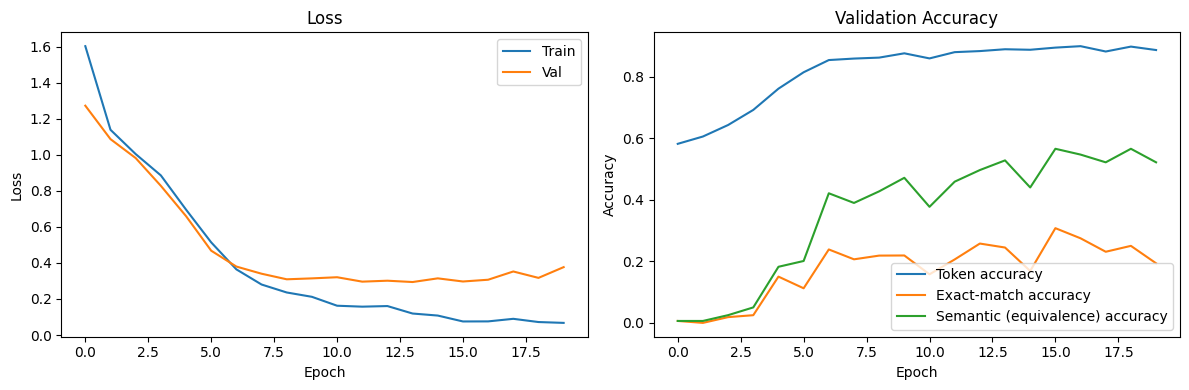

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].set_title("Loss")

axes[1].plot(history["val_token_acc"], label="Token accuracy")
axes[1].plot(history["val_exact_acc"], label="Exact-match accuracy")
axes[1].plot(history["val_semantic_acc"], label="Semantic (equivalence) accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].set_title("Validation Accuracy")
plt.tight_layout()
plt.show()

### Test set evaluation


In [ ]:
model.load_state_dict(torch.load(CHECKPOINT_DIR / "best_model.pth"))
test_loss, test_token_acc, test_exact_acc = run_epoch(test_loader, train=False)
test_exact_semantic, test_semantic_acc = semantic_eval(test_df)

print(f"Test loss: {test_loss:.4f} | Test token acc: {test_token_acc:.3f}")
print(f"Test exact-match acc: {test_exact_acc:.3f} | Test semantic (equivalence) acc: {test_semantic_acc:.3f}")

Test loss: 0.4131 | Test token acc: 0.877
Test exact-match acc: 0.306 | Test semantic (equivalence) acc: 0.594


### Greedy decoding

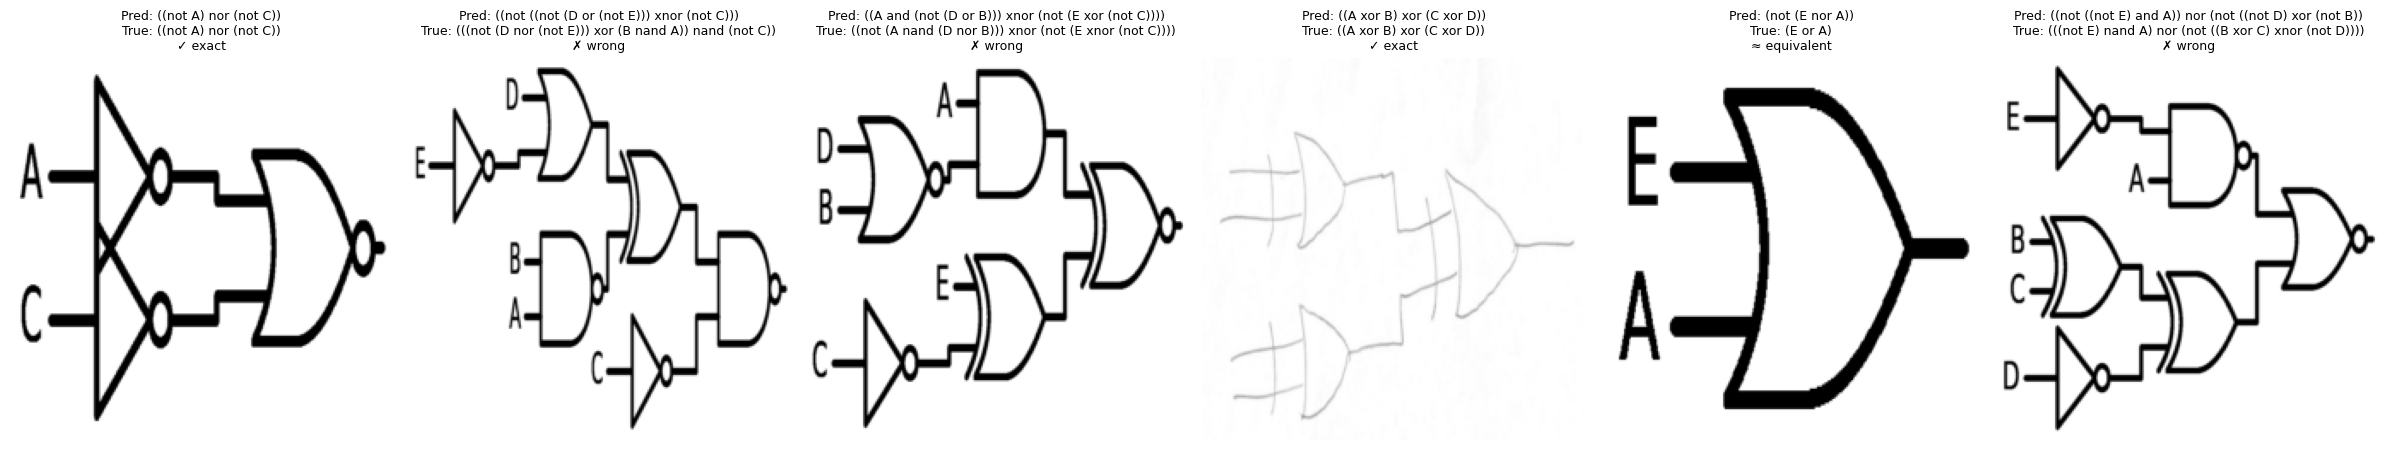

In [ ]:
n_show = 6
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4.5))
mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)

for i in range(n_show):
    img_tensor, label_ids = LogicDataset(val_df, eval_transform)[i]
    pred_expr = generate(model, img_tensor)
    true_expr = detokenize(label_ids.tolist())

    img_disp = img_tensor * std + mean
    axes[i].imshow(img_disp.permute(1, 2, 0).clamp(0, 1))
    match = "✓ exact" if pred_expr == true_expr else ("≈ equivalent" if are_equivalent(pred_expr, true_expr) else "✗ wrong")
    axes[i].set_title(f"Pred: {pred_expr}\nTrue: {true_expr}\n{match}", fontsize=9)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

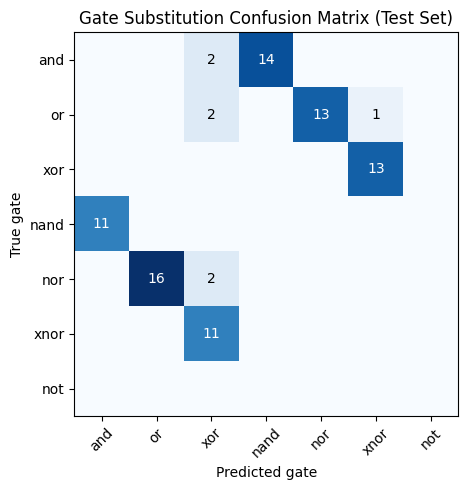

In [ ]:
import difflib
import numpy as np
import matplotlib.pyplot as plt

GATE_TOKENS = ["and", "or", "xor", "nand", "nor", "xnor", "not"]
gate_idx = {g: i for i, g in enumerate(GATE_TOKENS)}

def find_gate_substitutions(true_expr, pred_expr):
    true_tokens = tokenize_str(true_expr)
    pred_tokens = tokenize_str(pred_expr)
    sm = difflib.SequenceMatcher(None, true_tokens, pred_tokens)
    subs = []
    for op, i1, i2, j1, j2 in sm.get_opcodes():
        if op == "replace" and (i2 - i1) == (j2 - j1):
            for t_tok, p_tok in zip(true_tokens[i1:i2], pred_tokens[j1:j2]):
                if t_tok in GATE_TOKENS and p_tok in GATE_TOKENS:
                    subs.append((t_tok, p_tok))
    return subs

matrix = np.zeros((len(GATE_TOKENS), len(GATE_TOKENS)), dtype=int)
for idx in range(len(test_df)):
    img_tensor, label_ids = LogicDataset(test_df, eval_transform)[idx]
    pred_expr = generate(model, img_tensor)
    true_expr = detokenize(label_ids.tolist())
    for t_tok, p_tok in find_gate_substitutions(true_expr, pred_expr):
        matrix[gate_idx[t_tok], gate_idx[p_tok]] += 1

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matrix, cmap="Blues")
ax.set_xticks(range(len(GATE_TOKENS))); ax.set_xticklabels(GATE_TOKENS, rotation=45)
ax.set_yticks(range(len(GATE_TOKENS))); ax.set_yticklabels(GATE_TOKENS)
ax.set_xlabel("Predicted gate"); ax.set_ylabel("True gate")
ax.set_title("Gate Substitution Confusion Matrix (Test Set)")
for i in range(len(GATE_TOKENS)):
    for j in range(len(GATE_TOKENS)):
        if matrix[i, j] > 0:
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center",
                     color="white" if matrix[i,j] > matrix.max()/2 else "black")
plt.tight_layout()
plt.savefig("cnn_gate_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()